In [10]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path

# Add the repository root so src.regression can be imported from this notebook
sys.path.append(str(Path.cwd().parent))
from src.regression import train, predict

# Load dataset from the sibling data folder
data = pd.read_csv("../data/real_estate_price_size.csv", sep="\t")

# Prepare training data (size = X, price = y)
training_data = list(zip(data["size"], data["price"]))

# Feature mapping: phi(x) = [1, x] for bias + slope
w = train(training_data)
print("Final weights:", w)

# Predict new values
predictions = predict([200000, 300000, 400000], w)
print("Predictions:", predictions)

ImportError: cannot import name 'train' from 'src.regression' (c:\Users\User\Documents\Visual Studio 2022\Code Snippets\Python\ML_Algorithms_From_Scratch\src\regression.py)

Columns: Index(['daily_customer', 'daily_revenue'], dtype='str')
   daily_customer  daily_revenue
0             122    2104.585954
1             199    3001.341676
2             112    1936.446424
3              34     712.550067
4             126    2137.319325
Train size: 80
Test size: 20
Slope: 14.9949
Intercept: 207.3793
Equation: revenue = 14.99 * customers + 207.38
MSE: 9423.291146052734
R2: 0.991118590906536
60 customers/day -> predicted revenue: 1107.07
120 customers/day -> predicted revenue: 2006.77
200 customers/day -> predicted revenue: 3206.36


c:\Users\User\Documents\Visual Studio 2022\Code Snippets\Python\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


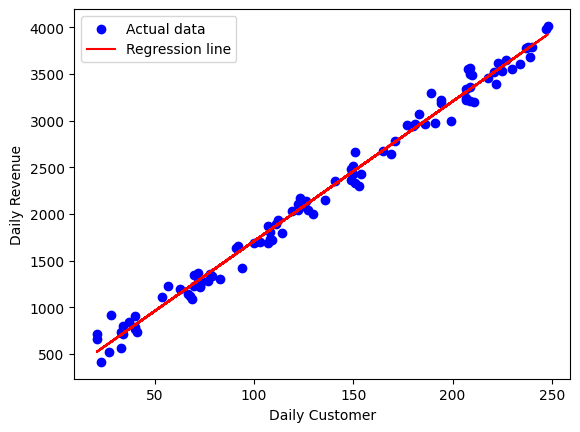

In [4]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


# Load dataset from the sibling data folder
data = pd.read_csv("../data/restaurant.csv", sep="\t")

# Use the updated column names from your file
X = data[["daily_customer"]]   # independent variable
y = data["daily_revenue"]      # dependent variable

print("Columns:", data.columns)   # quick check
print(data.head())                # preview first rows

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"Equation: revenue = {slope:.2f} * customers + {intercept:.2f}")

# Evaluate
y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

# Predictions for new scenarios
new_customers = [[60], [120], [200]]
predictions = model.predict(new_customers)
for c, p in zip([60, 120, 200], predictions):
    print(f"{c} customers/day -> predicted revenue: {p:.2f}")

# Visualization
plt.scatter(X, y, color="blue", label="Actual data")
plt.plot(X, model.predict(X), color="red", label="Regression line")
plt.xlabel("Daily Customer")
plt.ylabel("Daily Revenue")
plt.legend()
plt.show()



